### datasets (copy in terminal)
#!/bin/bash
kaggle datasets download masoudnickparvar/brain-tumor-mri-dataset

Number of images: 5600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Image shape: torch.Size([3, 224, 224])
Label: 0
Class name: glioma


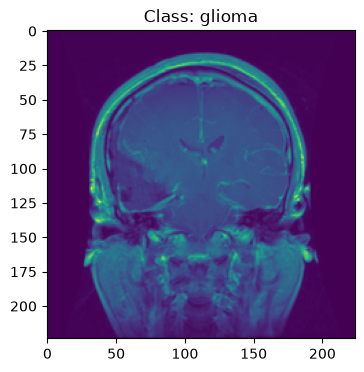

In [70]:
from pathlib import Path
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image
import random

# 数据路径（保持相对路径或根据需要调整）
TRAINING_DATA_DIR = Path("../data/brain_mri/Training/")
TESTING_DATA_DIR = Path("../data/brain_mri/Testing/")

transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]
)

training_dataset = datasets.ImageFolder(
    root=TRAINING_DATA_DIR,
    transform=transform,
)

print("Number of images:", len(training_dataset))
print("Classes:", training_dataset.classes)
print("Class mapping:", training_dataset.class_to_idx)

image, label = training_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class name:", training_dataset.classes[label])

plt.figure(figsize=(4, 4))
plt.imshow(image[0])  # 将通道维度移到最后以便显示
plt.title(f"Class: {training_dataset.classes[label]}")
plt.show()


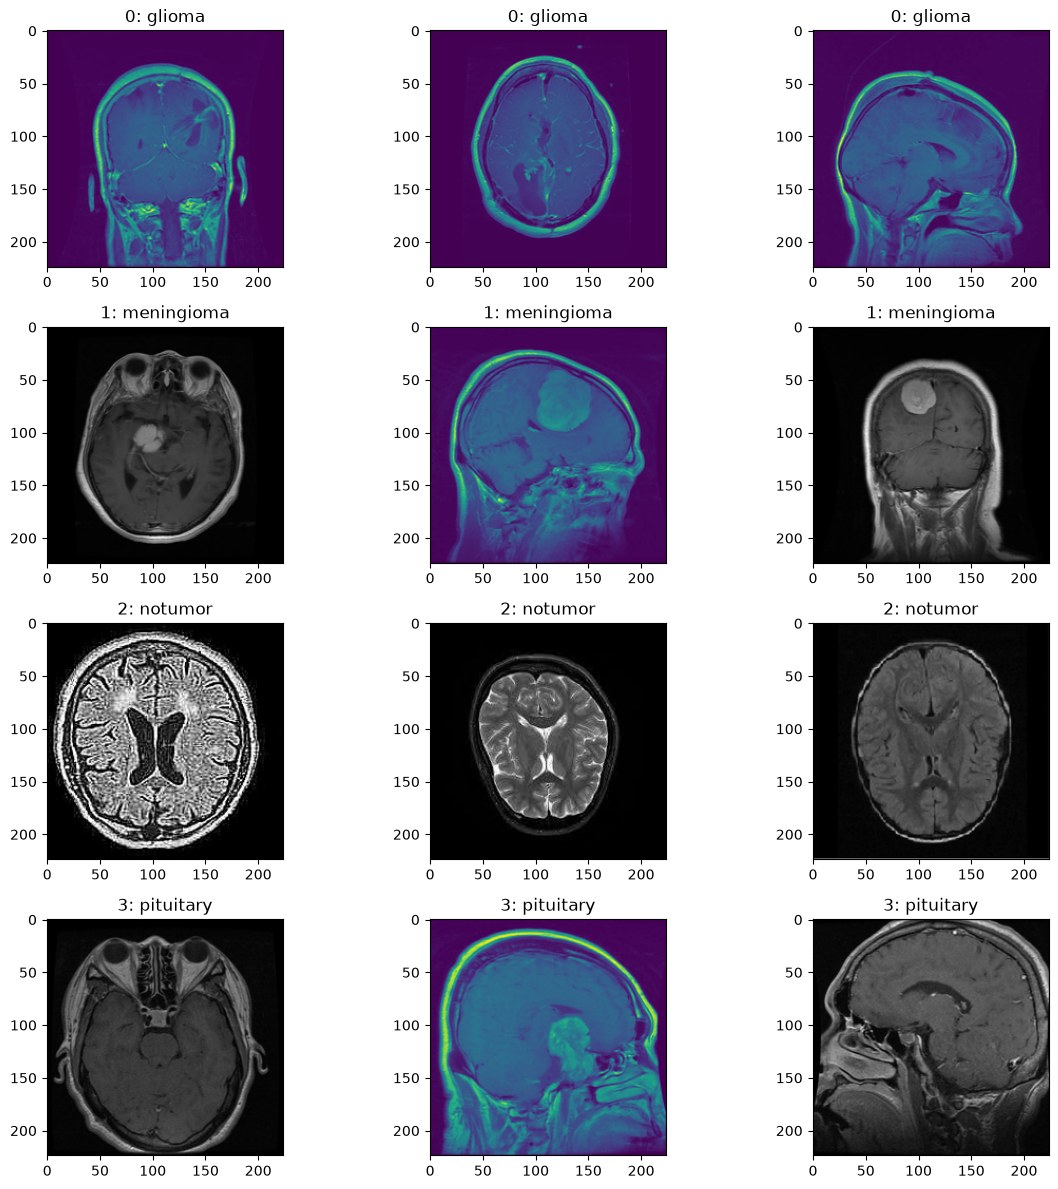

In [73]:
# 随机展示每个类别的 3 张图片，按行排列（每行一个类别）
classes = training_dataset.classes
samples = training_dataset.samples  # list of (path, class_idx)

fig, axes = plt.subplots(4, 3, figsize=(12, 12))

for i, cls in enumerate(classes):
    cls_samples = [p for p, idx in samples if idx == i]
    chosen = random.sample(cls_samples, 3)
    for j in range(3):
        ax = axes[i, j]
        img = Image.open(chosen[j]).resize((224, 224))  # 转换为 (H, W, C) 以便显示
        ax.imshow(img)
        ax.set_title(f"{i}: {cls}")

plt.tight_layout()
plt.show()